##Prestação de Contas Eleitorais - 2024
Prestação de contas de órgãos partidários - Prestação de contas de candidatos - CNPJ de campanha - Extratos Bancários

Fonte: URL: https://cdn.tse.jus.br/estatistica/sead/odsele/prestacao_contas/prestacao_de_contas_eleitorais_candidatos_2024.zip


Para onde foi o dinheiro das campanhas municipais no Ceará em 2024?

Análise exploratória das despesas de campanha declaradas ao TSE nas Eleições Municipais de 2024, recorte do estado do Ceará.

Stack: Python · Pandas · NumPy · Matplotlib · Seaborn Fonte: Repositório de Dados Eleitorais do TSE — dados abertos Volume: 144.613 registros · 53 colunas · ~R$ 260 milhões · 184 municípios · 12.640 candidatos.

1 - Conhecimento e Tratamento dos Dados

In [81]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df = pd.read_csv('despesas_contratadas_candidatos_2024_CE.csv', sep=';', encoding='latin1')

print(df.head())


   DT_GERACAO HH_GERACAO  AA_ELEICAO  CD_TIPO_ELEICAO NM_TIPO_ELEICAO  \
0  14/09/2026   23:00:14        2024                2       Ordinária   
1  14/09/2026   23:00:14        2024                2       Ordinária   
2  14/09/2026   23:00:14        2024                2       Ordinária   
3  14/09/2026   23:00:14        2024                2       Ordinária   
4  14/09/2026   23:00:14        2024                2       Ordinária   

   CD_ELEICAO                DS_ELEICAO  DT_ELEICAO  ST_TURNO  \
0         619  Eleições Municipais 2024  06/10/2024         1   
1         619  Eleições Municipais 2024  06/10/2024         1   
2         619  Eleições Municipais 2024  06/10/2024         2   
3         619  Eleições Municipais 2024  06/10/2024         2   
4         619  Eleições Municipais 2024  06/10/2024         1   

  TP_PRESTACAO_CONTAS DT_PRESTACAO_CONTAS  SQ_PRESTADOR_CONTAS SG_UF  SG_UE  \
0               Final          09/11/2024           5280634836    CE  15490   
1           

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144613 entries, 0 to 144612
Data columns (total 53 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   DT_GERACAO                 144613 non-null  str  
 1   HH_GERACAO                 144613 non-null  str  
 2   AA_ELEICAO                 144613 non-null  int64
 3   CD_TIPO_ELEICAO            144613 non-null  int64
 4   NM_TIPO_ELEICAO            144613 non-null  str  
 5   CD_ELEICAO                 144613 non-null  int64
 6   DS_ELEICAO                 144613 non-null  str  
 7   DT_ELEICAO                 144613 non-null  str  
 8   ST_TURNO                   144613 non-null  int64
 9   TP_PRESTACAO_CONTAS        144613 non-null  str  
 10  DT_PRESTACAO_CONTAS        144613 non-null  str  
 11  SQ_PRESTADOR_CONTAS        144613 non-null  int64
 12  SG_UF                      144613 non-null  str  
 13  SG_UE                      144613 non-null  int64
 14  NM_UE          

In [83]:
print(df.columns)


Index(['DT_GERACAO', 'HH_GERACAO', 'AA_ELEICAO', 'CD_TIPO_ELEICAO',
       'NM_TIPO_ELEICAO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO', 'ST_TURNO',
       'TP_PRESTACAO_CONTAS', 'DT_PRESTACAO_CONTAS', 'SQ_PRESTADOR_CONTAS',
       'SG_UF', 'SG_UE', 'NM_UE', 'NR_CNPJ_PRESTADOR_CONTA', 'CD_CARGO',
       'DS_CARGO', 'SQ_CANDIDATO', 'NR_CANDIDATO', 'NM_CANDIDATO',
       'NR_CPF_CANDIDATO', 'NR_CPF_VICE_CANDIDATO', 'NR_PARTIDO', 'SG_PARTIDO',
       'NM_PARTIDO', 'CD_TIPO_FORNECEDOR', 'DS_TIPO_FORNECEDOR',
       'CD_CNAE_FORNECEDOR', 'DS_CNAE_FORNECEDOR', 'NR_CPF_CNPJ_FORNECEDOR',
       'NM_FORNECEDOR', 'NM_FORNECEDOR_RFB', 'CD_ESFERA_PART_FORNECEDOR',
       'DS_ESFERA_PART_FORNECEDOR', 'SG_UF_FORNECEDOR',
       'CD_MUNICIPIO_FORNECEDOR', 'NM_MUNICIPIO_FORNECEDOR',
       'SQ_CANDIDATO_FORNECEDOR', 'NR_CANDIDATO_FORNECEDOR',
       'CD_CARGO_FORNECEDOR', 'DS_CARGO_FORNECEDOR', 'NR_PARTIDO_FORNECEDOR',
       'SG_PARTIDO_FORNECEDOR', 'NM_PARTIDO_FORNECEDOR', 'DS_TIPO_DOCUMENTO',
      

In [84]:
print(df.isnull().sum())


DT_GERACAO                      0
HH_GERACAO                      0
AA_ELEICAO                      0
CD_TIPO_ELEICAO                 0
NM_TIPO_ELEICAO                 0
CD_ELEICAO                      0
DS_ELEICAO                      0
DT_ELEICAO                      0
ST_TURNO                        0
TP_PRESTACAO_CONTAS             0
DT_PRESTACAO_CONTAS             0
SQ_PRESTADOR_CONTAS             0
SG_UF                           0
SG_UE                           0
NM_UE                           0
NR_CNPJ_PRESTADOR_CONTA         0
CD_CARGO                        0
DS_CARGO                        0
SQ_CANDIDATO                    0
NR_CANDIDATO                    0
NM_CANDIDATO                    0
NR_CPF_CANDIDATO                0
NR_CPF_VICE_CANDIDATO           0
NR_PARTIDO                      0
SG_PARTIDO                      0
NM_PARTIDO                      0
CD_TIPO_FORNECEDOR              0
DS_TIPO_FORNECEDOR              0
CD_CNAE_FORNECEDOR              0
DS_CNAE_FORNEC

In [85]:
df.shape

(144613, 53)

In [86]:
df.head(2)

,DT_GERACAO,HH_GERACAO,AA_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,ST_TURNO,TP_PRESTACAO_CONTAS,DT_PRESTACAO_CONTAS,SQ_PRESTADOR_CONTAS,SG_UF,SG_UE,NM_UE,NR_CNPJ_PRESTADOR_CONTA,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NR_CPF_CANDIDATO,NR_CPF_VICE_CANDIDATO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,CD_TIPO_FORNECEDOR,DS_TIPO_FORNECEDOR,CD_CNAE_FORNECEDOR,DS_CNAE_FORNECEDOR,NR_CPF_CNPJ_FORNECEDOR,NM_FORNECEDOR,NM_FORNECEDOR_RFB,CD_ESFERA_PART_FORNECEDOR,DS_ESFERA_PART_FORNECEDOR,SG_UF_FORNECEDOR,CD_MUNICIPIO_FORNECEDOR,NM_MUNICIPIO_FORNECEDOR,SQ_CANDIDATO_FORNECEDOR,NR_CANDIDATO_FORNECEDOR,CD_CARGO_FORNECEDOR,DS_CARGO_FORNECEDOR,NR_PARTIDO_FORNECEDOR,SG_PARTIDO_FORNECEDOR,NM_PARTIDO_FORNECEDOR,DS_TIPO_DOCUMENTO,NR_DOCUMENTO,CD_ORIGEM_DESPESA,DS_ORIGEM_DESPESA,SQ_DESPESA,DT_DESPESA,DS_DESPESA,VR_DESPESA_CONTRATADA
0,14/09/2026,23:00:14,2024,2,Ordinária,619,Eleições Municipais 2024,06/10/2024,1,Final,09/11/2024,5280634836,CE,15490,SÃO GONÇALO DO AMARANTE,56623700000197,13,Vereador,60002190836,13013,SARA RAQUEL MORAIS VIANA,-4,-4,13,PT,Partido dos Trabalhadores,0,PESSOA FÍSICA,-1,#NULO,4786292303,IVANISIA DE LIMA SILVA,IVANISIA DE LIMA SILVA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,014,20800000,Atividades de militância e mobilização de rua,69219261,12/09/2024,ATIVISTA,"300,16"
1,14/09/2026,23:00:14,2024,2,Ordinária,619,Eleições Municipais 2024,06/10/2024,1,Final,14/12/2024,5265499412,CE,13080,TURURU,56410352000170,11,Prefeito,60002008881,44,RAIMUNDO NONATO MONTEIRO DO NASCIMENTO,-4,-4,44,UNIÃO,União Brasil,0,PESSOA FÍSICA,-1,#NULO,1651038333,MARIA LEDIANE ALVES FERREIRA,MARIA LEDIANE ALVES FERREIRA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,SN,20800000,Atividades de militância e mobilização de rua,71270846,09/09/2024,CONTRATO DE ATIVISTA,"300,00"


In [87]:
# 3.2 Datas
for col in ["DT_DESPESA", "DT_ELEICAO", "DT_PRESTACAO_CONTAS"]:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

2- Quantidade de Candidatos e TABELA DE FREQUÊNCIA ABSOLUTA E RELATIVA GERAL (CARGO x GÊNERO)

In [88]:


# 1. Carrega o arquivo de despesas
df = pd.read_csv('despesas_contratadas_candidatos_2024_CE.csv', sep=';', encoding='latin1', low_memory=False)

# 2. Filtra candidatos únicos por sequencial (SQ_CANDIDATO)
df_candidatos_unicos = df.drop_duplicates(subset=['SQ_CANDIDATO']).copy()

# 3. Contagem total geral de candidatos
total_candidatos = len(df_candidatos_unicos)

# 4. Contagem detalhada por cargo (DS_CARGO)
candidatos_por_cargo = df_candidatos_unicos['DS_CARGO'].value_counts().reset_index()
candidatos_por_cargo.columns = ['Cargo', 'Quantidade de Candidatos']

# 5. Adiciona o percentual correspondente a cada cargo
candidatos_por_cargo['Percentual (%)'] = (
    (candidatos_por_cargo['Quantidade de Candidatos'] / total_candidatos) * 100
).map('{:.2f}%'.format)

# Output dos resultados
print("==================================================")
print(f"TOTAL DE CANDIDATOS PARTICIPANTES NO PLEITO: {total_candidatos:,}".replace(',', '.'))
print("==================================================\n")

print("--- DISTRIBUIÇÃO DE CANDIDATOS POR CARGO ---")
print(candidatos_por_cargo.to_string(index=False))

TOTAL DE CANDIDATOS PARTICIPANTES NO PLEITO: 12.640

--- DISTRIBUIÇÃO DE CANDIDATOS POR CARGO ---
   Cargo  Quantidade de Candidatos Percentual (%)
Vereador                     12145         96.08%
Prefeito                       495          3.92%


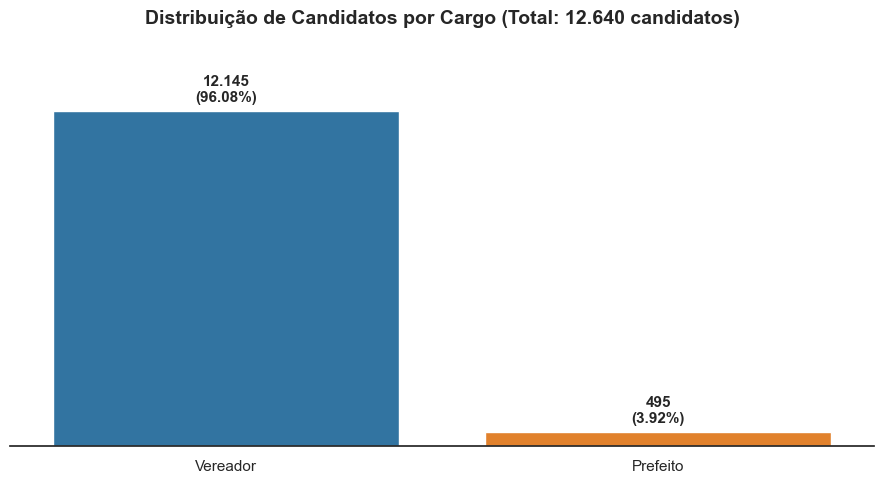

In [89]:


# 1. Preparação dos dados
df_candidatos_unicos = df.drop_duplicates(subset=['SQ_CANDIDATO']).copy()
total = len(df_candidatos_unicos)

freq_df = df_candidatos_unicos['DS_CARGO'].value_counts().reset_index()
freq_df.columns = ['Cargo', 'Quantidade']
freq_df['Percentual'] = (freq_df['Quantidade'] / total) * 100

# 2. Gráfico Seaborn
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9, 5))

barplot = sns.barplot(
    data=freq_df, 
    x='Cargo', 
    y='Quantidade', 
    hue='Cargo',
    palette=['#1f77b4', '#ff7f0e'],
    ax=ax
)

if ax.legend_:
    ax.legend_.remove()

# 3. Rótulos das barras contendo Frequência Absoluta e Relativa (%)
for i, row in freq_df.iterrows():
    qtd_str = f"{int(row['Quantidade']):,}".replace(',', '.')
    pct_str = f"{row['Percentual']:.2f}%"
    texto = f"{qtd_str}\n({pct_str})"
    
    ax.annotate(
        texto,
        (i, row['Quantidade']),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

# --- REMOÇÃO DO EIXO Y E DAS GRADES ---
ax.set_yticks([])          # Remove as marcas e valores do eixo Y
ax.grid(False)             # Garante que nenhuma grade de fundo seja exibida
sns.despine(left=True)     # Remove a linha da borda esquerda (eixo Y)

# 4. Títulos e eixos
plt.title(f'Distribuição de Candidatos por Cargo (Total: {total:,} candidatos)'.replace(',', '.'), 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')

# Limite superior para acomodar os textos
plt.ylim(0, freq_df['Quantidade'].max() * 1.18)

plt.tight_layout()
plt.show()

In [90]:

# 2. Filtra apenas os candidatos únicos para evitar duplicidade pelas despesas[cite: 1]
df_candidatos = df.drop_duplicates(subset=['SQ_CANDIDATO']).copy()

# 3. Extrai o primeiro nome do candidato[cite: 1]
df_candidatos['PRIMEIRO_NOME'] = df_candidatos['NM_CANDIDATO'].astype(str).str.split().str[0].str.upper()

# 4. Função de inferência por padrão de nome em português
def inferir_genero(nome):
    excecoes_masculinas = {'LUCA', 'LUCAS', 'ANDREA', 'JOSUE', 'ALEXANDRE', 'ATILA', 'GARCIA', 'ELIA', 'VALDIR'}
    excecoes_femininas = {'ALICE', 'BEATRIZ', 'RAQUEL', 'ELIS', 'INES', 'SUELI', 'MIRIAM', 'ISABEL', 'ESTHER', 'RUTH'}
    
    if nome in excecoes_masculinas:
        return 'Masculino'
    if nome in excecoes_femininas:
        return 'Feminino'
    
    # Nomes terminados em "A" geralmente são femininos em português
    if nome.endswith('A'):
        return 'Feminino'
    return 'Masculino'

# 5. Aplica a inferência aos nomes
df_candidatos['GENERO'] = df_candidatos['PRIMEIRO_NOME'].apply(inferir_genero)

# 6. Frequência Absoluta por Cargo x Gênero
freq_abs = pd.crosstab(df_candidatos['DS_CARGO'], df_candidatos['GENERO'], margins=True, margins_name='Total Absoluto')

# 7. Frequência Relativa Percentual dentro de cada Cargo (% por Linha)
freq_rel_cargo = pd.crosstab(
    df_candidatos['DS_CARGO'], 
    df_candidatos['GENERO'], 
    normalize='index'
) * 100

# Formata os valores percentuais para exibição
freq_rel_cargo_formatada = freq_rel_cargo.map('{:.2f}%'.format)

# Exibe os resultados
print("--- FREQUÊNCIA ABSOLUTA (QUANTIDADE) ---")
print(freq_abs)

print("\n--- PERCENTUAL RELATIVO POR CARGO (% DENTRO DE CADA CARGO) ---")
print(freq_rel_cargo_formatada)

--- FREQUÊNCIA ABSOLUTA (QUANTIDADE) ---
GENERO          Feminino  Masculino  Total Absoluto
DS_CARGO                                           
Prefeito              81        414             495
Vereador            3539       8606           12145
Total Absoluto      3620       9020           12640

--- PERCENTUAL RELATIVO POR CARGO (% DENTRO DE CADA CARGO) ---
GENERO   Feminino Masculino
DS_CARGO                   
Prefeito   16.36%    83.64%
Vereador   29.14%    70.86%


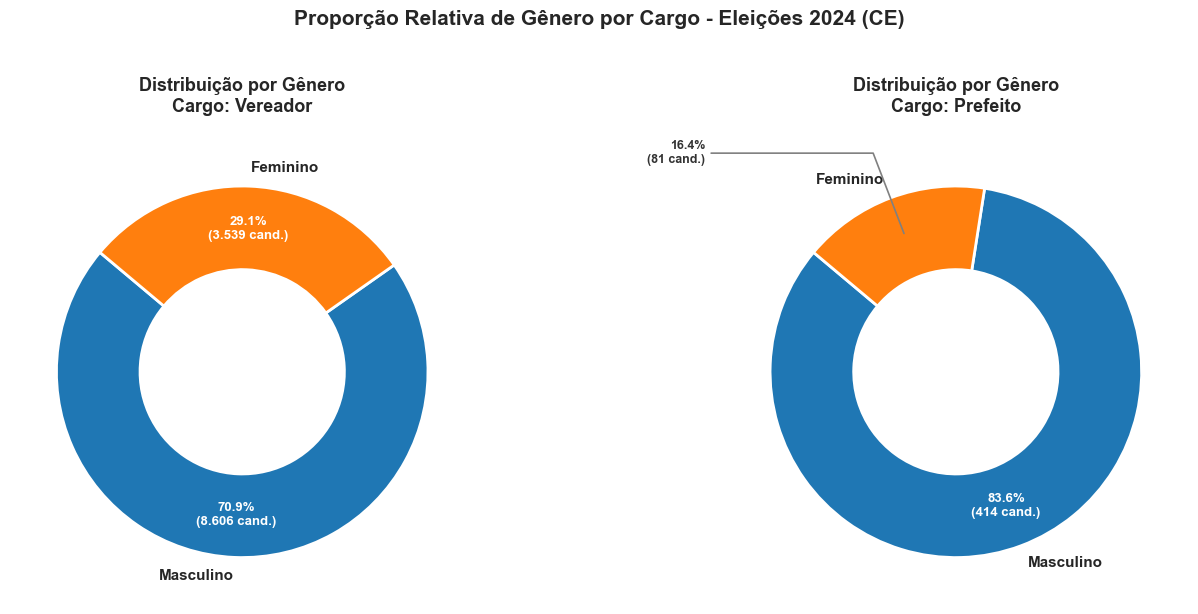

In [91]:


# 2. Filtra candidatos únicos para evitar duplicidades das notas de despesa
df_candidatos = df.drop_duplicates(subset=['SQ_CANDIDATO']).copy()

# 3. Extrai o primeiro nome do candidato
df_candidatos['PRIMEIRO_NOME'] = df_candidatos['NM_CANDIDATO'].astype(str).str.split().str[0].str.upper()

# 4. Função de inferência por padrão de nome em português
def inferir_genero(nome):
    excecoes_masculinas = {'LUCA', 'LUCAS', 'ANDREA', 'JOSUE', 'ALEXANDRE', 'ATILA', 'GARCIA', 'ELIA', 'VALDIR'}
    excecoes_femininas = {'ALICE', 'BEATRIZ', 'RAQUEL', 'ELIS', 'INES', 'SUELI', 'MIRIAM', 'ISABEL', 'ESTHER', 'RUTH'}
    
    if nome in excecoes_masculinas:
        return 'Masculino'
    if nome in excecoes_femininas:
        return 'Feminino'
    if nome.endswith('A'):
        return 'Feminino'
    return 'Masculino'

# 5. Aplica a inferência aos nomes
df_candidatos['GENERO'] = df_candidatos['PRIMEIRO_NOME'].apply(inferir_genero)

# 6. Configuração dos gráficos e paleta
cores_paleta = {'Masculino': '#1f77b4', 'Feminino': '#ff7f0e'}
cargos = df_candidatos['DS_CARGO'].unique()

fig, axes = plt.subplots(1, len(cargos), figsize=(14, 6))

for i, cargo in enumerate(cargos):
    dados_cargo = df_candidatos[df_candidatos['DS_CARGO'] == cargo]['GENERO'].value_counts()
    
    # Prepara as cores de acordo com a ordem das fatias
    cores_fatias = [cores_paleta[g] for g in dados_cargo.index]
    total_candidatos = dados_cargo.sum()

    # Desenha o gráfico de rosca (sem autopct para evitar sobreposição automática)
    wedges, texts = axes[i].pie(
        dados_cargo, 
        labels=dados_cargo.index, 
        startangle=140, 
        colors=cores_fatias,
        wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2), # Largura ideal da rosca
        textprops=dict(fontsize=11, weight='bold')
    )

    # Adiciona os rótulos de forma inteligente com setas explicativas para fatias pequenas
    for j, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        valor_abs = dados_cargo.iloc[j]
        percentual = (valor_abs / total_candidatos) * 100
        texto_rotulo = f"{percentual:.1f}%\n({valor_abs:,} cand.)".replace(',', '.')

        # Se a fatia for menor que 25%, projeta o texto para fora com uma seta
        if percentual < 25:
            horizontalalignment = "left" if x > 0 else "right"
            connectionstyle = f"angle,angleA=0,angleB={ang:.0f}"
            axes[i].annotate(
                texto_rotulo, 
                xy=(x * 0.78, y * 0.78), 
                xytext=(1.35 * np.sign(x), 1.2 * y),
                horizontalalignment=horizontalalignment,
                fontsize=9,
                fontweight='bold',
                color='#333333',
                arrowprops=dict(arrowstyle="-", connectionstyle=connectionstyle, color="gray", lw=1.2)
            )
        else:
            # Se for uma fatia grande, coloca o texto diretamente dentro da rosca
            axes[i].text(
                x * 0.77, y * 0.77, 
                texto_rotulo, 
                ha='center', va='center', 
                fontsize=9.5, fontweight='bold', color='white'
            )

    axes[i].set_title(f'Distribuição por Gênero\nCargo: {cargo}', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Proporção Relativa de Gênero por Cargo - Eleições 2024 (CE)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

3 - Valor Total Gasto na Campanha, Valor Gasto por Cargo e Valor Gasto por Partido e TOP 10 Prefeitos com maiores gastos.

In [92]:

#Tratamento e padronização do valor monetário


# Substitui a vírgula por ponto na coluna e depois converte para numérico
df['VR_DESPESA_CONTRATADA_CLEAN'] = (
    df['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.replace('.', '', regex=False)   # Remove ponto de milhar (se houver, ex: 1.300,16)
    .str.replace(',', '.', regex=False)   # Troca vírgula por ponto decimal
)

# Converte para float de forma segura
df['VR_DESPESA_CONTRATADA_CLEAN'] = pd.to_numeric(df['VR_DESPESA_CONTRATADA_CLEAN'], errors='coerce').fillna(0)

# GARANTIA: Converte explicitamente a coluna limpa para float
df['VR_DESPESA_CONTRATADA_CLEAN'] = df['VR_DESPESA_CONTRATADA_CLEAN'].astype(float)

# --- ANÁLISES ---

# A. Valor Total Gasto em Campanha
total_gasto = float(df['VR_DESPESA_CONTRATADA_CLEAN'].sum()) # Força para float nativo
print(f"Total Gasto em Campanha: R$ {total_gasto:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

# B. Valor Gasto por Cargo (Prefeito vs Vereador)
gasto_cargo = df.groupby('DS_CARGO')['VR_DESPESA_CONTRATADA_CLEAN'].sum().reset_index()
gasto_cargo['VR_FORMATADO'] = gasto_cargo['VR_DESPESA_CONTRATADA_CLEAN'].apply(lambda x: f"R$ {x:,.2f}")
print("\n--- Gasto por Cargo ---")
print(gasto_cargo[['DS_CARGO', 'VR_FORMATADO']])

# C. Ranking dos Partidos que Mais Gastaram
ranking_partidos = (
    df.groupby(['SG_PARTIDO', 'NM_PARTIDO'])['VR_DESPESA_CONTRATADA_CLEAN']
    .sum()
    .reset_index()
    .sort_values(by='VR_DESPESA_CONTRATADA_CLEAN', ascending=False)
)
ranking_partidos['VR_FORMATADO'] = ranking_partidos['VR_DESPESA_CONTRATADA_CLEAN'].apply(lambda x: f"R$ {x:,.2f}")
print("\n--- Top 10 Partidos com Maiores Gastos ---")
print(ranking_partidos[['SG_PARTIDO', 'NM_PARTIDO', 'VR_FORMATADO']].head(10))

# D. Ranking dos Prefeitos que Mais Gastaram
df_prefeitos = df[df['DS_CARGO'].str.upper() == 'PREFEITO']
ranking_prefeitos = (
    df_prefeitos.groupby(['SQ_CANDIDATO', 'NM_CANDIDATO', 'NM_UE', 'SG_PARTIDO'])['VR_DESPESA_CONTRATADA_CLEAN']
    .sum()
    .reset_index()
    .sort_values(by='VR_DESPESA_CONTRATADA_CLEAN', ascending=False)
)
ranking_prefeitos['VR_FORMATADO'] = ranking_prefeitos['VR_DESPESA_CONTRATADA_CLEAN'].apply(lambda x: f"R$ {x:,.2f}")
print("\n--- Top 10 Prefeitos com Maiores Gastos ---")
print(ranking_prefeitos[['NM_CANDIDATO', 'NM_UE', 'SG_PARTIDO', 'VR_FORMATADO']].head(10))

Total Gasto em Campanha: R$ 260.226.100,67

--- Gasto por Cargo ---
   DS_CARGO       VR_FORMATADO
0  Prefeito  R$ 169,117,784.17
1  Vereador   R$ 91,108,316.50

--- Top 10 Partidos com Maiores Gastos ---
      SG_PARTIDO                               NM_PARTIDO      VR_FORMATADO
24            PT                Partido dos Trabalhadores  R$ 51,145,897.19
11            PL                          Partido Liberal  R$ 34,639,084.54
30         UNIÃO                             União Brasil  R$ 32,735,999.76
10           PDT          Partido Democrático Trabalhista  R$ 27,223,579.34
19           PSD               Partido Social Democrático  R$ 23,395,389.73
18           PSB            Partido Socialista Brasileiro  R$ 23,314,499.96
4            MDB         Movimento Democrático Brasileiro  R$ 11,271,321.88
27  REPUBLICANOS                             REPUBLICANOS  R$ 10,774,326.99
14            PP                            PROGRESSISTAS   R$ 9,373,449.98
20          PSDB  Partido da Social

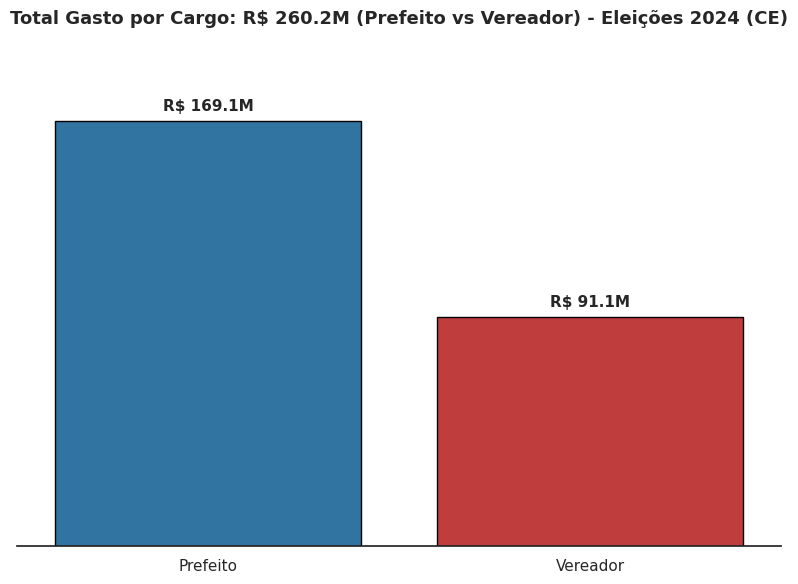

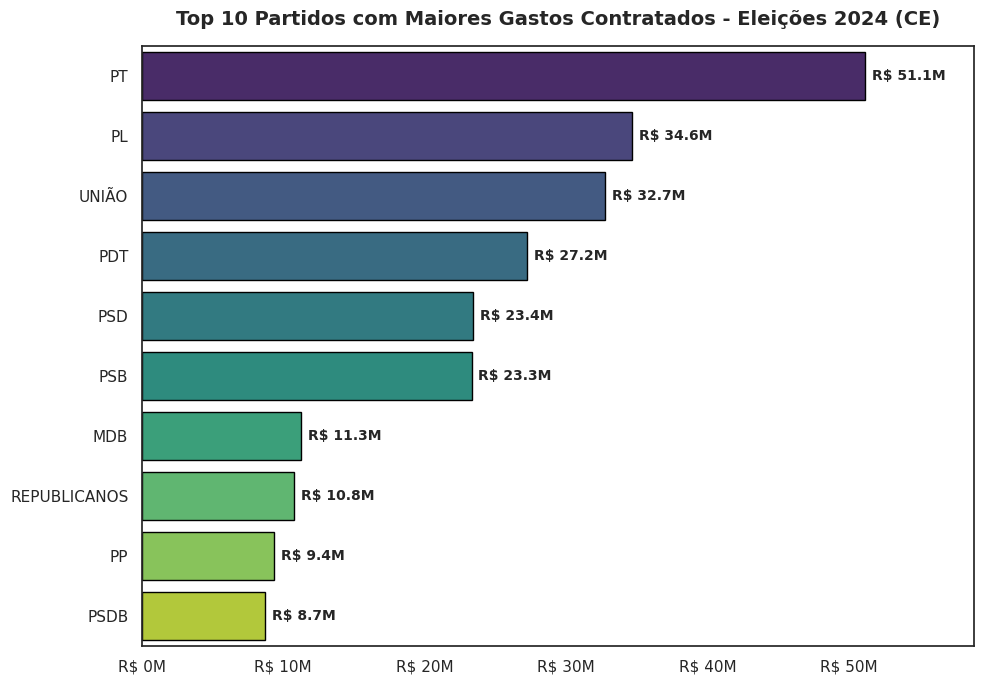

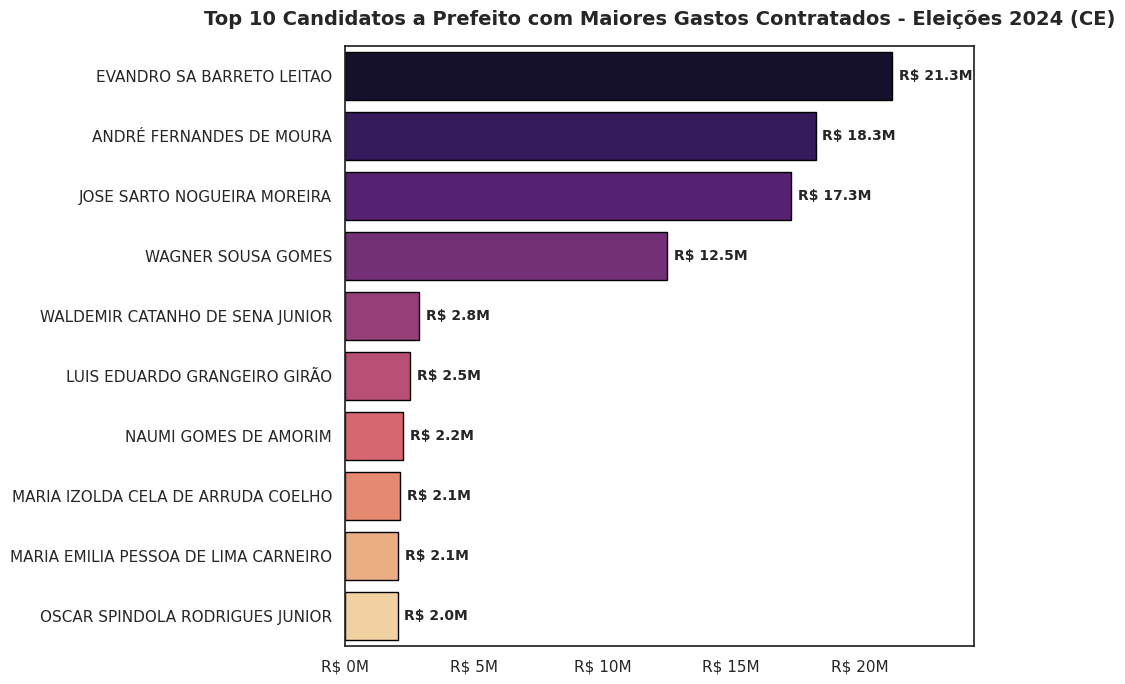

In [93]:


# --- ESTE BLOCO DEVE VIR APÓS O SEU CÓDIGO DE TRATAMENTO ---
# (Assumindo que o DataFrame 'df' já contém 'VR_DESPESA_CONTRATADA_CLEAN' processado)

# --- PROCESSAMENTO ADICIONAL PARA GRÁFICOS ---

# B. Gasto por Cargo (Já calculado no seu código como 'gasto_cargo')

# C. Ranking dos Partidos (Selecionando Top 10 e simplificando)
# Usaremos apenas a sigla e o valor
top10_partidos = ranking_partidos.head(10)[['SG_PARTIDO', 'VR_DESPESA_CONTRATADA_CLEAN']]

# D. Ranking dos Prefeitos (Selecionando Top 10 e simplificando)
# Usaremos apenas o nome e o valor
top10_prefeitos = ranking_prefeitos.head(10)[['NM_CANDIDATO', 'VR_DESPESA_CONTRATADA_CLEAN']]

# --- ELABORAÇÃO DOS GRÁFICOS COM MATPLOTLIB/SEABORN ---

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo geral
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. Gráfico de Coluna: Gasto por Cargo
plt.figure(figsize=(8, 6))

ax1 = sns.barplot(
    data=gasto_cargo,
    x='DS_CARGO',
    y='VR_DESPESA_CONTRATADA_CLEAN',
    hue='DS_CARGO',
    palette=['#1f77b4', '#d62728'], # Azul e Vermelho
    edgecolor='black'
)

# Remove a legenda automática gerada pelo hue
if ax1.legend_:
    ax1.legend_.remove()

# 2. Adiciona os rótulos de valor nas barras (em Milhões)
for p in ax1.patches:
    altura = p.get_height()
    if altura > 0:
        ax1.annotate(
            f"R$ {altura/1e6:.1f}M",
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

# 3. Calcula o valor total dinamicamente e insere no título
total_gasto = gasto_cargo['VR_DESPESA_CONTRATADA_CLEAN'].sum()

plt.title(
    f'Total Gasto por Cargo: R$ {total_gasto/1e6:.1f}M (Prefeito vs Vereador) - Eleições 2024 (CE)', 
    fontsize=13, fontweight='bold', pad=15
)
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')

# 4. Remove a grade de fundo, marcas do eixo Y e bordas desnecessárias
ax1.set_yticks([])
ax1.grid(False)
sns.despine(left=True, top=True, right=True)

# Limite superior para garantir que o rótulo da barra não corte
plt.ylim(0, gasto_cargo['VR_DESPESA_CONTRATADA_CLEAN'].max() * 1.18)

plt.tight_layout()
plt.show()

# 2. Gráfico de Barras (Ranking): Top 10 Partidos com Maiores Gastos
plt.figure(figsize=(10, 7))
ax2 = sns.barplot(
    data=top10_partidos,
    y='SG_PARTIDO', # Barras Horizontais
    x='VR_DESPESA_CONTRATADA_CLEAN',
    hue='SG_PARTIDO',                # <- Atribua a coluna do eixo y
    legend=False,
    palette='viridis',
    edgecolor='black'
)

# Adicionando rótulos de valor nas barras (em Milhões)
for p in ax2.patches:
    largura = p.get_width()
    if largura > 0:
        ax2.annotate(
            f"R$ {largura/1e6:.1f}M",
            (largura, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

plt.title('Top 10 Partidos com Maiores Gastos Contratados - Eleições 2024 (CE)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {int(x/1e6)}M')) # X em Milhões

# Limite X para rótulos não cortarem
plt.xlim(0, top10_partidos['VR_DESPESA_CONTRATADA_CLEAN'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. Gráfico de Barras (Ranking): Top 10 Prefeitos com Maiores Gastos
plt.figure(figsize=(10, 7))
ax3 = sns.barplot(
    data=top10_prefeitos,
    y='NM_CANDIDATO', # Barras Horizontais
    x='VR_DESPESA_CONTRATADA_CLEAN',
    hue='NM_CANDIDATO',              # <- Atribua a coluna do eixo y
    legend=False,
    palette='magma',
    edgecolor='black'
)

# Adicionando rótulos de valor nas barras (em Milhões)
for p in ax3.patches:
    largura = p.get_width()
    if largura > 0:
        ax3.annotate(
            f"R$ {largura/1e6:.1f}M",
            (largura, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

plt.title('Top 10 Candidatos a Prefeito com Maiores Gastos Contratados - Eleições 2024 (CE)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {int(x/1e6)}M')) # X em Milhões

# Limite X para rótulos não cortarem
plt.xlim(0, top10_prefeitos['VR_DESPESA_CONTRATADA_CLEAN'].max() * 1.15)

plt.tight_layout()
plt.show()

3.1 - Top 10 Vereadores que mais Gastaram

In [94]:
# 2. Tratamento e conversão limpa do valor monetário
df['VR_DESPESA_CONTRATADA_CLEAN'] = (
    df['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df['VR_DESPESA_CONTRATADA_CLEAN'] = pd.to_numeric(
    df['VR_DESPESA_CONTRATADA_CLEAN'], 
    errors='coerce'
).fillna(0.0).astype(float)

# 3. Filtra apenas candidatos ao cargo de Vereador
df_vereadores = df[df['DS_CARGO'].str.upper() == 'VEREADOR']

# 4. Agrupa por candidato e soma as despesas contratadas
top10_vereadores = (
    df_vereadores.groupby(['SQ_CANDIDATO', 'NM_CANDIDATO', 'SG_PARTIDO', 'NM_UE'])['VR_DESPESA_CONTRATADA_CLEAN']
    .sum()
    .reset_index()
    .sort_values(by='VR_DESPESA_CONTRATADA_CLEAN', ascending=False)
    .head(10)
)

# 5. Formatação monetária em R$
top10_vereadores['VALOR_TOTAL'] = top10_vereadores['VR_DESPESA_CONTRATADA_CLEAN'].apply(
    lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
)

# Exibe as colunas solicitadas
resultado = top10_vereadores[['NM_CANDIDATO', 'SG_PARTIDO', 'NM_UE', 'VALOR_TOTAL']]
print(resultado.to_string(index=False))

                                NM_CANDIDATO   SG_PARTIDO     NM_UE   VALOR_TOTAL
ISABELLA ANTÔNNIA CASALE ROCHA CARNEIRO LEÃO           PL FORTALEZA R$ 682.506,71
                ERICH DOUGLAS MOREIRA CHAVES          PSD FORTALEZA R$ 672.674,91
                       LARISSA DUARTE AGUIAR        UNIÃO FORTALEZA R$ 661.999,10
                   PRISCILA BEZERRA DA COSTA           PL FORTALEZA R$ 500.637,45
                    RONALDO MANCHADO MARTINS REPUBLICANOS FORTALEZA R$ 447.540,68
                       MARCIO DA CRUZ FARIAS      PC do B FORTALEZA R$ 438.790,00
              ANDREIA VIANA DE OLIVEIRA LIMA           PL FORTALEZA R$ 409.640,62
                       JULIERME LIMA DE SENA           PL FORTALEZA R$ 404.893,72
                      MAIRTON FELIX FERREIRA           PL FORTALEZA R$ 399.056,01
        FRANCISCO WELLINGTON SABÓIA VITORINO         PODE FORTALEZA R$ 338.440,80


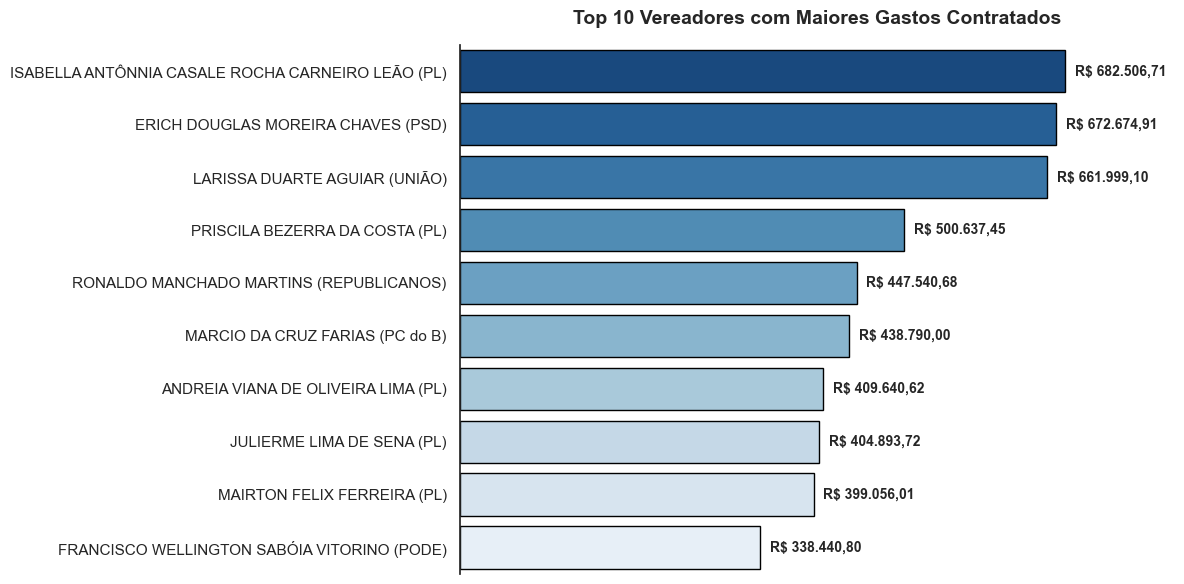

In [95]:

# 1. Cria uma coluna formatada combinando o Nome do Candidato e Partido para o eixo Y
top10_vereadores['CANDIDATO_PARTIDO'] = (
    top10_vereadores['NM_CANDIDATO'] + " (" + top10_vereadores['SG_PARTIDO'] + ")"
)

# 2. Configurações visuais do gráfico
sns.set_theme(style="white", palette="muted")
plt.figure(figsize=(12, 6))

# 3. Cria o gráfico de barras horizontais
ax = sns.barplot(
    data=top10_vereadores,
    y='CANDIDATO_PARTIDO',
    x='VR_DESPESA_CONTRATADA_CLEAN',
    hue='CANDIDATO_PARTIDO',
    legend=False,              # Evita aviso de depreciação no Seaborn v0.13+
    palette='Blues_r',         # Gradiente de cores do azul escuro ao claro
    edgecolor='black'
)

# Remove legenda gerada pelo hue
if ax.legend_:
    ax.legend_.remove()

# 4. Adiciona o valor gasto formatado (R$) na ponta de cada barra
for p in ax.patches:
    largura = p.get_width()
    if largura > 0:
        valor_formatado = f"R$ {largura:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        ax.annotate(
            valor_formatado,
            (largura, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(7, 0), textcoords='offset points'
        )

# 5. Remove as grades de fundo e oculta os números/marcas do eixo X
ax.grid(False)
ax.set_xticks([])

# 7. Remove as bordas desnecessárias (superior, direita e inferior)
sns.despine(bottom=True, top=True, right=True)
# 8. Ajusta títulos e eixos
plt.title('Top 10 Vereadores com Maiores Gastos Contratados', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=11, fontweight='bold')
plt.ylabel('', fontsize=11, fontweight='bold')

# Expande o limite do eixo X para que os textos das barras não fiquem cortados
plt.xlim(0, top10_vereadores['VR_DESPESA_CONTRATADA_CLEAN'].max() * 1.18)

plt.tight_layout()
plt.show()

3.2 - Média e Mediana de Gastos por Prefeito e Vereador

In [96]:
# 2. Tratamento e padronização do valor monetário
df['VR_DESPESA_CONTRATADA_CLEAN'] = (
    df['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df['VR_DESPESA_CONTRATADA_CLEAN'] = pd.to_numeric(
    df['VR_DESPESA_CONTRATADA_CLEAN'], 
    errors='coerce'
).fillna(0.0).astype(float)

# 3. Média e Mediana do Gasto TOTAL acumulado por Candidato (SQ_CANDIDATO)[cite: 1]
df_candidato_total = (
    df.groupby(['DS_CARGO', 'SQ_CANDIDATO'])['VR_DESPESA_CONTRATADA_CLEAN']
    .sum()
    .reset_index()
)

stats_candidatos = (
    df_candidato_total.groupby('DS_CARGO')['VR_DESPESA_CONTRATADA_CLEAN']
    .agg(
        MEDIA=('mean'),
        MEDIANA=('median'),
        QTD_CANDIDATOS=('count')
    )
    .reset_index()
)

# Formatação em Moeda (R$)
stats_candidatos['MEDIA_FORMATADA'] = stats_candidatos['MEDIA'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
stats_candidatos['MEDIANA_FORMATADA'] = stats_candidatos['MEDIANA'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

print("--- MÉDIA E MEDIANA DO TOTAL GASTO POR CANDIDATO ---")
print(stats_candidatos[['DS_CARGO', 'MEDIA_FORMATADA', 'MEDIANA_FORMATADA', 'QTD_CANDIDATOS']])

--- MÉDIA E MEDIANA DO TOTAL GASTO POR CANDIDATO ---
   DS_CARGO MEDIA_FORMATADA MEDIANA_FORMATADA  QTD_CANDIDATOS
0  Prefeito   R$ 341.652,09     R$ 137.409,16             495
1  Vereador     R$ 7.501,71       R$ 2.000,00           12145


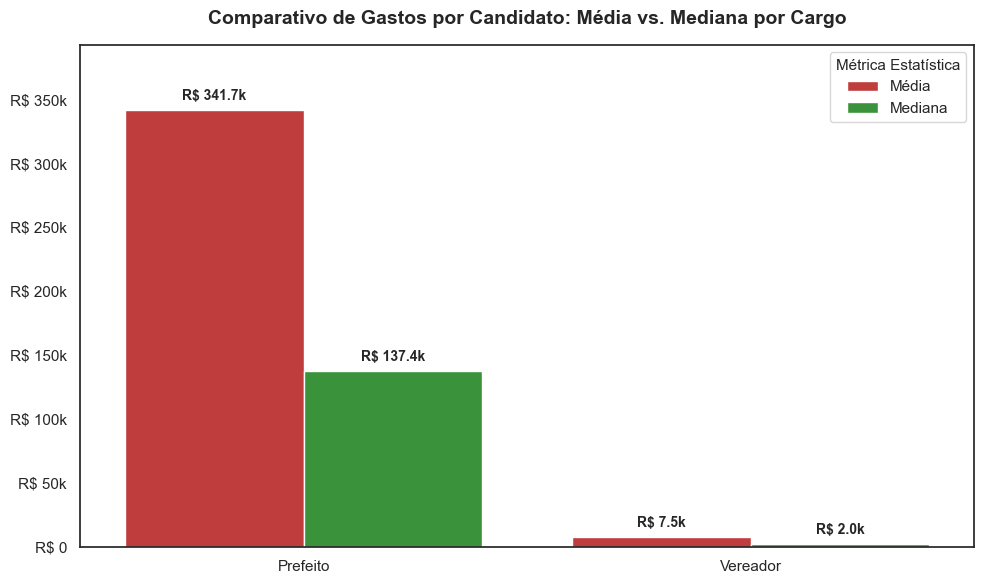

In [97]:

# 1. Reorganiza os dados de 'stats_candidatos' para o formato longo (ideal para o Seaborn)
stats_melted = stats_candidatos.melt(
    id_vars=['DS_CARGO'], 
    value_vars=['MEDIA', 'MEDIANA'], 
    var_name='Métrica', 
    value_name='Valor'
)

# Renomeia as métricas para exibição amigável
stats_melted['Métrica'] = stats_melted['Métrica'].map({'MEDIA': 'Média', 'MEDIANA': 'Mediana'})

# 2. Configuração do estilo visual
sns.set_theme(style="white", palette="muted")
plt.figure(figsize=(10, 6))

# 3. Criação do gráfico de barras agrupadas
ax = sns.barplot(
    data=stats_melted, 
    x='DS_CARGO', 
    y='Valor', 
    hue='Métrica', 
    palette=['#d62728', '#2ca02c']  # Vermelho para Média, Verde para Mediana
)

# 4. Adição dos rótulos de valor sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        # Formatação em R$ (com 'k' para milhares se for maior que 1000)
        texto = f"R$ {altura/1e3:,.1f}k" if altura >= 1000 else f"R$ {altura:,.2f}"
        ax.annotate(
            texto,
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )

# 5. Títulos e eixos
plt.title('Comparativo de Gastos por Candidato: Média vs. Mediana por Cargo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')

# Formatação do eixo Y em milhares (R$ k)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {int(x/1e3)}k' if x >= 1e3 else f'R$ {int(x)}'))

# Ajuste dos limites para os rótulos não cortarem
plt.ylim(0, stats_melted['Valor'].max() * 1.15)
plt.legend(title='Métrica Estatística', fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.show()

4- Ranking de Empresas que mais Receberam Dinheiro na Campanha Eleitoral de 2024

In [98]:


# 2. Tratamento e padronização do valor monetário
df['VR_DESPESA_CONTRATADA_CLEAN'] = (
    df['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df['VR_DESPESA_CONTRATADA_CLEAN'] = pd.to_numeric(
    df['VR_DESPESA_CONTRATADA_CLEAN'], 
    errors='coerce'
).fillna(0.0).astype(float)

# 3. Função de padronização de CPF / CNPJ
def formatar_cpf_cnpj(valor):
    val_str = str(valor).strip()
    digitos = ''.join(filter(str.isdigit, val_str))
    if not digitos or val_str.startswith('-'):
        return None
    if len(digitos) <= 11:
        cpf = digitos.zfill(11)
        return f"{cpf[:3]}.{cpf[3:6]}.{cpf[6:9]}-{cpf[9:]}"
    elif len(digitos) <= 14:
        cnpj = digitos.zfill(14)
        return f"{cnpj[:2]}.{cnpj[2:5]}.{cnpj[5:8]}/{cnpj[8:12]}-{cnpj[12:]}"
    return val_str

df['NR_CPF_CNPJ_FORNECEDOR_PADRAO'] = df['NR_CPF_CNPJ_FORNECEDOR'].apply(formatar_cpf_cnpj)

# 4. Agrupamento pelo CNPJ/CPF padronizado
ranking_fornecedores = (
    df.groupby('NR_CPF_CNPJ_FORNECEDOR_PADRAO')
    .agg(
        NM_FORNECEDOR=('NM_FORNECEDOR', lambda x: x.mode()[0] if not x.empty else ''),
        TOTAL_RECEBIDO=('VR_DESPESA_CONTRATADA_CLEAN', 'sum'),
        QTD_DESPESAS=('VR_DESPESA_CONTRATADA_CLEAN', 'count')
    )
    .reset_index()
    .sort_values(by='TOTAL_RECEBIDO', ascending=False)
)

# 5. Formatação segura para exibição
ranking_fornecedores['TOTAL_FORMATADO'] = ranking_fornecedores['TOTAL_RECEBIDO'].apply(
    lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
)

# Exibe o Top 10 empresas que mais receberam
print(ranking_fornecedores[['NR_CPF_CNPJ_FORNECEDOR_PADRAO', 'NM_FORNECEDOR', 'TOTAL_FORMATADO', 'QTD_DESPESAS']].head(10))

      NR_CPF_CNPJ_FORNECEDOR_PADRAO  \
24568            13.347.016/0001-17   
30095            44.355.509/0001-22   
31863            52.264.807/0001-35   
26436            25.021.356/0001-32   
3237             02.933.302/0001-48   
24716            14.097.991/0001-87   
14941            07.012.214/0001-27   
8                00.212.872/0001-13   
7155             04.405.470/0001-96   
28520            37.653.361/0001-47   

                                       NM_FORNECEDOR   TOTAL_FORMATADO  \
24568        FACEBOOK SERVICOS ONLINE DO BRASIL LTDA  R$ 16.155.324,10   
30095                        TRITON CONSULTORIA LTDA   R$ 6.700.000,00   
31863              PLTK COMUNICAÇÃO ESTRATEGICA LTDA   R$ 5.330.400,00   
26436    DLOCAL BRASIL INSTITUICAO DE PAGAMENTO S.A.   R$ 4.528.246,57   
3237                QUALIGRAF EDITORA E GRAFICA LTDA   R$ 4.200.406,90   
24716             RH8 SERVICOS E TERCEIRIZACOES LTDA   R$ 3.043.588,52   
14941          GRAFICA E EDITORA POUCHAIN RAMOS LTDA

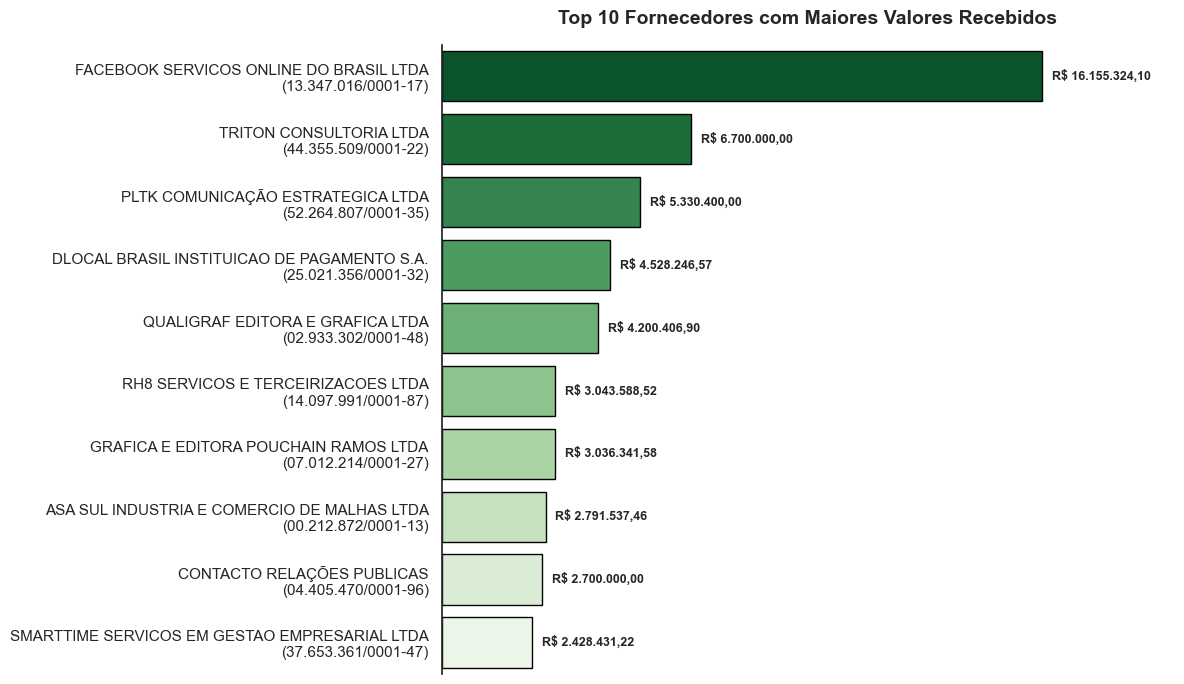

In [99]:

# 1. Filtra os Top 10 e cria um rótulo com Nome e CPF/CNPJ
top10_fornecedores = ranking_fornecedores.head(10).copy()
top10_fornecedores['FORNECEDOR_ROTULO'] = (
    top10_fornecedores['NM_FORNECEDOR'] + "\n(" + top10_fornecedores['NR_CPF_CNPJ_FORNECEDOR_PADRAO'] + ")"
)

# 2. Configurações do layout
plt.figure(figsize=(12, 7))

# 3. Criação do gráfico de barras horizontais
ax = sns.barplot(
    data=top10_fornecedores,
    y='FORNECEDOR_ROTULO',
    x='TOTAL_RECEBIDO',
    hue='FORNECEDOR_ROTULO',
    legend=False,              # Para versões recentes do Seaborn
    palette='Greens_r',
    edgecolor='black'
)

# 4. Adiciona os rótulos de valores em R$ na ponta das barras
for p in ax.patches:
    largura = p.get_width()
    if largura > 0:
        valor_formatado = f"R$ {largura:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        ax.annotate(
            valor_formatado,
            (largura, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=9, fontweight='bold',
            xytext=(7, 0), textcoords='offset points'
        )

# 5. Remove as grades de fundo
plt.grid(False)

# 6. Oculta os valores/marcas (ticks) e título do eixo X
ax.set_xticks([])
plt.xlabel('')

# 7. Remove as linhas de borda desnecessárias (superior, direita e inferior)
sns.despine(bottom=True, top=True, right=True)

# 8. Título e eixos
plt.title('Top 10 Fornecedores com Maiores Valores Recebidos', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, top10_fornecedores['TOTAL_RECEBIDO'].max() * 1.22)
plt.ylabel('', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()

5- Tipos de Gastos nas Eleições de 2024 

In [100]:


# 2. Tratamento do valor monetário (remoção de pontos de milhar e troca de vírgula por ponto)
df['VR_DESPESA_CONTRATADA_CLEAN'] = (
    df['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df['VR_DESPESA_CONTRATADA_CLEAN'] = pd.to_numeric(
    df['VR_DESPESA_CONTRATADA_CLEAN'], 
    errors='coerce'
).fillna(0.0).astype(float)

# 3. Agrupamento por Origem da Despesa
origem_despesas = (
    df.groupby('DS_ORIGEM_DESPESA')
    .agg(
        TOTAL_GASTO=('VR_DESPESA_CONTRATADA_CLEAN', 'sum'),
        QTD_REGISTROS=('VR_DESPESA_CONTRATADA_CLEAN', 'count')
    )
    .reset_index()
    .sort_values(by='TOTAL_GASTO', ascending=False)
)

# 4. Formatação segura em reais (R$) para exibição
origem_despesas['TOTAL_FORMATADO'] = origem_despesas['TOTAL_GASTO'].apply(
    lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
)

# Exibe o resultado das despesas por origem
print(origem_despesas[['DS_ORIGEM_DESPESA', 'TOTAL_FORMATADO', 'QTD_REGISTROS']])

                                    DS_ORIGEM_DESPESA   TOTAL_FORMATADO  \
32                Publicidade por materiais impressos  R$ 50.185.881,41   
36                   Serviços prestados por terceiros  R$ 34.779.106,65   
3       Atividades de militância e mobilização de rua  R$ 31.755.622,43   
9            Despesa com Impulsionamento de Conteúdos  R$ 22.864.068,44   
29                           Publicidade por adesivos  R$ 19.110.461,56   
34                              Serviços advocatícios  R$ 17.887.928,88   
35                                 Serviços contábeis  R$ 12.635.104,39   
14                             Diversas a especificar  R$ 12.159.520,33   
27  Produção de programas de rádio, televisão ou v...  R$ 11.550.092,40   
4                       Cessão ou locação de veículos   R$ 8.222.845,42   
12                               Despesas com pessoal   R$ 5.680.999,92   
26            Produção de jingles, vinhetas e slogans   R$ 5.395.143,81   
5                        

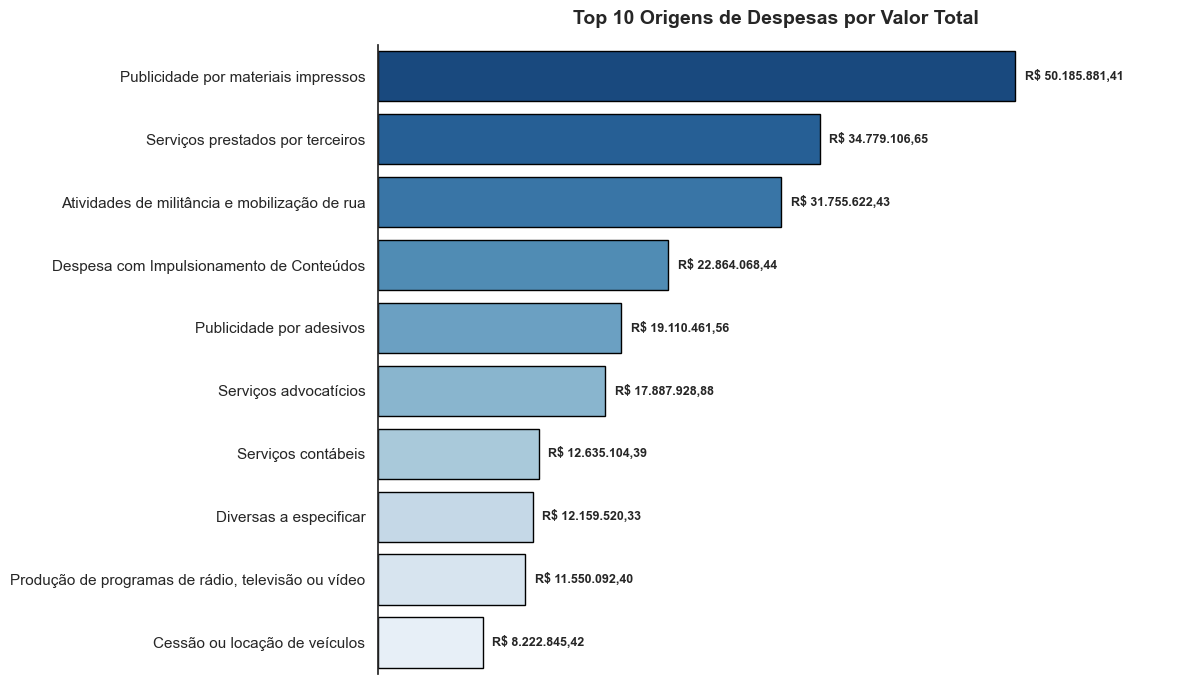

In [101]:

# 1. Seleciona o Top 10 das origens de despesas
top10_origem = origem_despesas.head(10).copy()

# 2. Configurações visuais do gráfico
plt.figure(figsize=(12, 7))

# 3. Gráfico de barras horizontais
ax = sns.barplot(
    data=top10_origem,
    y='DS_ORIGEM_DESPESA',
    x='TOTAL_GASTO',
    hue='DS_ORIGEM_DESPESA',
    legend=False,              # Garante compatibilidade sem warnings no Seaborn v0.13+
    palette='Blues_r',         # Gradiante em tons de azul
    edgecolor='black'
)

# 4. Adiciona os rótulos com valores em R$ na ponta das barras
for p in ax.patches:
    largura = p.get_width()
    if largura > 0:
        valor_formatado = f"R$ {largura:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        ax.annotate(
            valor_formatado,
            (largura, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=9, fontweight='bold',
            xytext=(7, 0), textcoords='offset points'
        )

# 5. Remove as grades e oculta os valores do eixo X
plt.grid(False)
ax.set_xticks([])
plt.xlabel('')

# 6. Remove bordas desnecessárias
sns.despine(bottom=True, top=True, right=True)

# 7. Título e eixos
plt.title('Top 10 Origens de Despesas por Valor Total', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('', fontsize=11, fontweight='bold')

# Margem para os rótulos de valores não cortarem na direita
plt.xlim(0, top10_origem['TOTAL_GASTO'].max() * 1.25)

plt.tight_layout()
plt.show()

6- Gastos por Fornecedor: Pessoa Física e Jurídica

In [102]:


# 2. Tratamento e conversão limpa do valor monetário
df['VR_DESPESA_CONTRATADA_CLEAN'] = (
    df['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df['VR_DESPESA_CONTRATADA_CLEAN'] = pd.to_numeric(
    df['VR_DESPESA_CONTRATADA_CLEAN'], 
    errors='coerce'
).fillna(0.0).astype(float)

# 3. Agrupamento consolidado por Pessoa Física vs Pessoa Jurídica
resumo_tipo_fornecedor = (
    df.groupby('DS_TIPO_FORNECEDOR')
    .agg(
        TOTAL_RECEBIDO=('VR_DESPESA_CONTRATADA_CLEAN', 'sum'),
        QTD_DESPESAS=('VR_DESPESA_CONTRATADA_CLEAN', 'count')
    )
    .reset_index()
    .sort_values(by='TOTAL_RECEBIDO', ascending=False)
)

# Formatação monetária em R$
resumo_tipo_fornecedor['TOTAL_FORMATADO'] = resumo_tipo_fornecedor['TOTAL_RECEBIDO'].apply(
    lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
)

print("--- RESUMO TOTAL: PESSOA FÍSICA VS PESSOA JURÍDICA ---")
print(resumo_tipo_fornecedor[['DS_TIPO_FORNECEDOR', 'TOTAL_FORMATADO', 'QTD_DESPESAS']])

# 4. Detalhamento por Fornecedor (CPF/CNPJ, Nome, Tipo e Valor Total)
ranking_detalhado = (
    df.groupby(['NR_CPF_CNPJ_FORNECEDOR', 'NM_FORNECEDOR', 'DS_TIPO_FORNECEDOR'])
    .agg(
        TOTAL_RECEBIDO=('VR_DESPESA_CONTRATADA_CLEAN', 'sum'),
        QTD_DESPESAS=('VR_DESPESA_CONTRATADA_CLEAN', 'count')
    )
    .reset_index()
    .sort_values(by='TOTAL_RECEBIDO', ascending=False)
)

ranking_detalhado['TOTAL_FORMATADO'] = ranking_detalhado['TOTAL_RECEBIDO'].apply(
    lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
)

print("\n--- TOP 10 MAIORES RECEBIMENTOS DETALHADOS POR FORNECEDOR ---")
print(ranking_detalhado[['NR_CPF_CNPJ_FORNECEDOR', 'NM_FORNECEDOR', 'DS_TIPO_FORNECEDOR', 'TOTAL_FORMATADO']].head(10))

--- RESUMO TOTAL: PESSOA FÍSICA VS PESSOA JURÍDICA ---
  DS_TIPO_FORNECEDOR    TOTAL_FORMATADO  QTD_DESPESAS
2    PESSOA JURÍDICA  R$ 198.283.411,82         93064
1      PESSOA FÍSICA   R$ 61.942.688,85         48866
0              #NULO            R$ 0,00          2683

--- TOP 10 MAIORES RECEBIMENTOS DETALHADOS POR FORNECEDOR ---
       NR_CPF_CNPJ_FORNECEDOR                                NM_FORNECEDOR  \
40764          13347016000117      FACEBOOK SERVICOS ONLINE DO BRASIL LTDA   
45617          44355509000122                      TRITON CONSULTORIA LTDA   
40786          13347016000117           FACEBOOK SERVIÇOS ONLINE DO BRASIL   
46878          52264807000135            PLTK COMUNICAÇÃO ESTRATEGICA LTDA   
42664          25021356000132                 DLOCAL A SERVIÇO DE FACEBOOK   
40952          14097991000187           RH8 SERVICOS E TERCEIRIZACOES LTDA   
38665           2933302000148             QUALIGRAF EDITORA E GRAFICA LTDA   
38942           4405470000196             

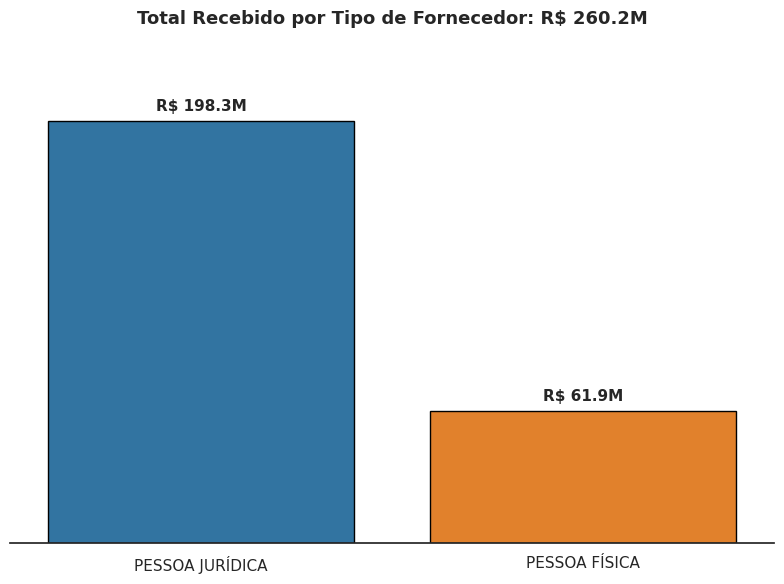

In [103]:


# 1. Filtra a DataFrame removendo valores nulos e/ou zerados
resumo_tipo_fornecedor = resumo_tipo_fornecedor[
    (resumo_tipo_fornecedor['DS_TIPO_FORNECEDOR'].notnull()) & 
    (resumo_tipo_fornecedor['TOTAL_RECEBIDO'] > 0)
].copy()

# 2. Configuração de estilo geral (clean, sem grades)
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

plt.figure(figsize=(8, 6))

# 3. Gráfico de colunas apenas com registros válidos
ax = sns.barplot(
    data=resumo_tipo_fornecedor,
    x='DS_TIPO_FORNECEDOR',
    y='TOTAL_RECEBIDO',
    hue='DS_TIPO_FORNECEDOR',
    palette=['#1f77b4', '#ff7f0e'], # Azul e Laranja
    edgecolor='black'
)

# Remove legenda automática gerada pelo hue
if ax.legend_:
    ax.legend_.remove()

# 4. Rótulos de valor no topo de cada coluna
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        texto = f"R$ {altura/1e6:.1f}M" if altura >= 1e6 else f"R$ {altura/1e3:.1f}k"
        ax.annotate(
            texto,
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

# 5. Cálculo do valor total consolidado
total_geral = resumo_tipo_fornecedor['TOTAL_RECEBIDO'].sum()

# Título dinâmico
plt.title(
    f'Total Recebido por Tipo de Fornecedor: R$ {total_geral/1e6:.1f}M', 
    fontsize=13, fontweight='bold', pad=15
)
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')

# 6. Oculta eixo Y, remove grades e bordas
ax.set_yticks([])
ax.grid(False)
sns.despine(left=True, top=True, right=True)

# Margem superior para acomodar o texto das colunas
plt.ylim(0, resumo_tipo_fornecedor['TOTAL_RECEBIDO'].max() * 1.18)

plt.tight_layout()
plt.show()